# 👩‍💻 Build a Basic RNN to Model Sequential Patterns

## 📋 Overview
In this lab, you will build a Recurrent Neural Network (RNN) from scratch using PyTorch to model and predict character sequences. RNNs are powerful neural network architectures designed specifically for sequential data, maintaining a form of "memory" that allows them to learn patterns over time. You'll create a model that can recognize and predict the next character in repeating patterns, similar to how predictive text works in real-world applications.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:

- Generate and prepare sequential data for RNN processing
- Implement a basic RNN architecture using PyTorch's nn.RNN module
- Train an RNN to recognize patterns in character sequences
- Visualize and interpret the predictions of your RNN model

## 🚀 Starting Point

In [1]:
# Starter code imports
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)

Required tools/setup:

- PyTorch installed
- Matplotlib for visualization
- Basic understanding of neural networks and tensors

## Task 1: Prepare Synthetic Sequential Data
**Context:** In real-world applications like text prediction or DNA sequence analysis, we need to convert character sequences into numerical representations that neural networks can process.

**Steps:**

1. Generate a simple repeating character sequence to serve as your dataset

In [2]:
# Create a repeating sequence
# YOUR CODE HERE

sequence = "abcabcabcabcabc"  # Simple repeating pattern
chars = sorted(list(set(sequence)))  # Get unique characters

2. Create mappings between characters and indices

In [3]:
# Create character to index and index to character mappings
# YOUR CODE HERE

# Create character to index mappings
char_to_idx = {ch: idx for idx, ch in enumerate(chars)}
idx_to_char = {idx: ch for ch, idx in char_to_idx.items()}

3. Convert your sequence into numerical format

In [4]:
# Convert characters to indices
# YOUR CODE HERE
sequence_indices = [char_to_idx[ch] for ch in sequence]

4. Create input and target tensors by offsetting the sequence by one position

In [5]:
# Create input tensor (all but last character) and target tensor (all but first character)
# YOUR CODE HERE
input_tensor = torch.tensor(sequence_indices[:-1], dtype=torch.float32).view(1, -1, 1)
target_tensor = torch.tensor(sequence_indices[1:], dtype=torch.long).view(1, -1)

print(f"Character mappings: {char_to_idx}")
print(f"Input tensor shape: {input_tensor.shape}")
print(f"Target tensor shape: {target_tensor.shape}")

Character mappings: {'a': 0, 'b': 1, 'c': 2}
Input tensor shape: torch.Size([1, 14, 1])
Target tensor shape: torch.Size([1, 14])


**💡 Tip:** For RNNs, your input is typically the current sequence, and your target is the sequence shifted by one position (to predict the next item in the sequence).

**⚙️ Test Your Work:**

- Print your character mapping dictionaries
- Verify the shapes of your input and target tensors
- Expected output: Input shape should be [1, sequence_length-1, 1] and target should match but offset by one position

## Task 2: Build the RNN Model
**Context:** RNNs are used in many industries for sequence modeling, from voice assistants predicting your next word to financial systems forecasting stock prices.

**Steps:**

1. Define a basic RNN class using PyTorch's nn.Module

In [ ]:
# Create an RNN class inheriting from nn.Module
# YOUR CODE HERE

2. Implement the constructor with appropriate layers
    - Use nn.RNN for the recurrent layer
    - Use nn.Linear for the output layer

In [ ]:
# Initialize the RNN and Linear layers
# YOUR CODE HERE

3. Implement the forward method to process sequences. The nn.RNN layer expects input shape [batch, sequence, input_size] (with batch_first=True) and outputs [batch, sequence, hidden_size]. The nn.Linear layer maps the hidden state to the output size (number of unique characters).

In [ ]:
# Define the forward pass
# YOUR CODE HERE

4. Add a helper method to initialize the hidden state

In [ ]:
# Add a method to initialize the hidden state
# YOUR CODE HERE

5. Initialize your model with appropriate dimensions

In [6]:
# Initialize model with input_size, hidden_size, and output_size
# YOUR CODE HERE

# Task 2: Build the RNN Model
class BasicRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(BasicRNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, hidden):
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out)
        return out, hidden
    
    def init_hidden(self, batch_size=1):
        return torch.zeros(1, batch_size, self.hidden_size)

# Initialize model with appropriate dimensions
input_size = 1  # Single feature (character index)
hidden_size = 16  # Hidden layer size
output_size = len(chars)  # Number of possible characters
model = BasicRNN(input_size, hidden_size, output_size)

print(model)

BasicRNN(
  (rnn): RNN(1, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=3, bias=True)
)


**💡 Tip:** The `batch_first=True` parameter in nn.RNN changes the tensor shape requirement to [batch, sequence, features] which is often more intuitive to work with.

**⚙️ Test Your Work:**

- Print your model architecture
- Run a test sequence through the model
- Expected output: A tensor of predictions and an updated hidden state

## Task 3: Train the RNN
**Context:** Training sequential models requires handling both the sequence data and evolving hidden states across time steps.

**Steps:**

1. Define your loss function and optimizer

In [7]:
# Set up loss function and optimizer
# YOUR CODE HERE

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

2. Create a training loop

In [8]:
# Create a loop for training iterations
# YOUR CODE HERE

# Training loop
n_epochs = 20
losses = []

for epoch in range(n_epochs):
    # Initialize hidden state
    hidden = model.init_hidden()
    
    # Forward pass
    output, hidden = model(input_tensor, hidden)
    
    # Reshape output for loss calculation
    output = output.view(-1, output_size)
    target = target_tensor.view(-1)
    
    # Calculate loss
    loss = criterion(output, target)
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Store loss
    losses.append(loss.item())
    
    # Print progress
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 1.1126


3. Inside the loop, initialize the hidden state for each sequence

In [9]:
# Initialize hidden state
# YOUR CODE HERE

4. Forward pass: get predictions from the model

In [10]:
# Forward pass
# YOUR CODE HERE

5. Calculate loss between predictions and targets

In [11]:
# Calculate loss
# YOUR CODE HERE

6. Perform backpropagation and update weights

In [12]:
# Backward pass and optimization
# YOUR CODE HERE

7. Track and store loss values for visualization

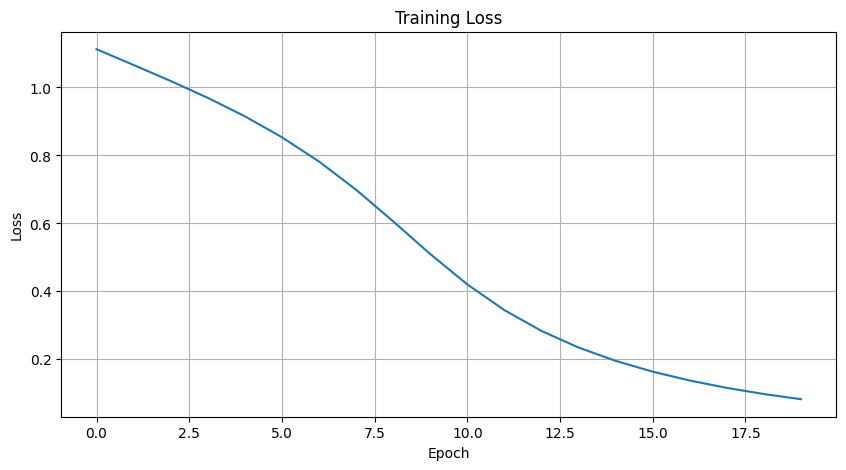

In [13]:
# Store loss values
# YOUR CODE HERE

plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

**💡 Tip:** Detaching the hidden state (hidden.detach_()) prevents backpropagation through the entire sequence history, which is useful for long sequences to avoid exploding gradients.

**⚙️ Test Your Work:**

- Plot the training loss to verify it's decreasing
- Expected output: A downward trending loss curve

## Task 4: Evaluate and Visualize Results
**Context:** Visualization helps us understand the model's learning progress and performance on sequence prediction tasks.

**Steps:**

1. Prepare the model for evaluation mode

In [14]:
# Set model to evaluation mode
# YOUR CODE HERE

model.eval()

BasicRNN(
  (rnn): RNN(1, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=3, bias=True)
)

2. Generate predictions for a test sequence

In [15]:
# Generate predictions
# YOUR CODE HERE

# Generate predictions
with torch.no_grad():
    hidden = model.init_hidden()
    output, hidden = model(input_tensor, hidden)
    
    # Get predicted indices
    _, predicted_indices = torch.max(output.view(-1, output_size), 1)
    predicted_chars = [idx_to_char[idx.item()] for idx in predicted_indices]
    
    # Convert input to characters for comparison
    input_chars = [idx_to_char[int(idx.item())] for idx in input_tensor.view(-1)]
    target_chars = [idx_to_char[idx.item()] for idx in target_tensor.view(-1)]

print(f"Input sequence: {''.join(input_chars)}")
print(f"Target sequence: {''.join(target_chars)}")
print(f"Predicted sequence: {''.join(predicted_chars)}")

Input sequence: abcabcabcabcab
Target sequence: bcabcabcabcabc
Predicted sequence: bcabcabcabcabc


3. Convert numerical predictions back to characters

In [ ]:
# Convert predictions to characters
# YOUR CODE HERE

4. Visualize the original sequence vs predicted sequence

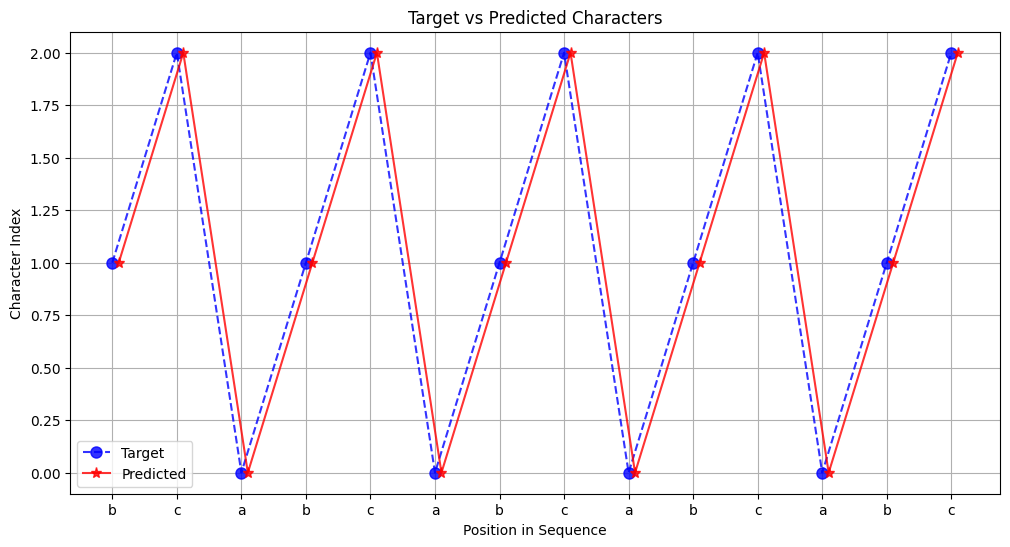

In [16]:
# Visualize results
# YOUR CODE HERE

# Visualize predictions vs targets
plt.figure(figsize=(12, 6))
# Plot target with distinct style
plt.plot(range(len(target_chars)), [char_to_idx[c] for c in target_chars], 
         'bo--', label='Target', markersize=8, alpha=0.8)
# Plot predicted with distinct style and slight offset for visibility
plt.plot([x + 0.1 for x in range(len(predicted_chars))], [char_to_idx[c] for c in predicted_chars], 
         'r*-', label='Predicted', markersize=8, alpha=0.8)
plt.title('Target vs Predicted Characters')
plt.xlabel('Position in Sequence')
plt.ylabel('Character Index')
plt.xticks(range(len(target_chars)), target_chars)  # Show characters on x-axis
plt.grid(True)
plt.legend()
plt.show()

5. Create a visualization of the hidden state evolution over time

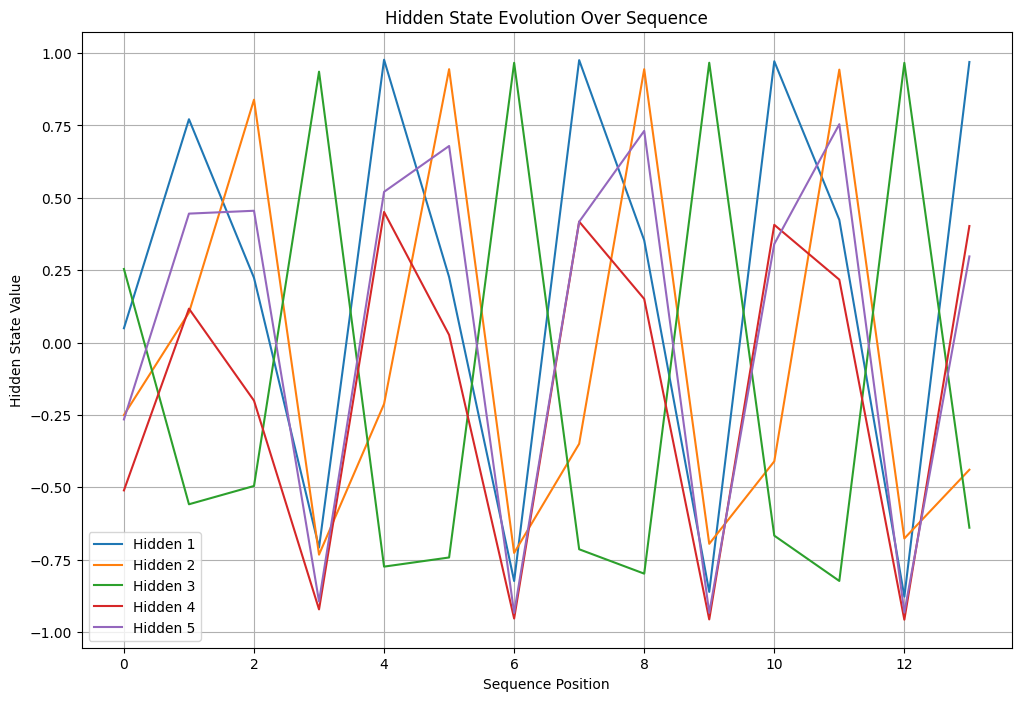

In [17]:
# Visualize hidden state changes
# YOUR CODE HERE

with torch.no_grad():
    hidden = model.init_hidden()
    hidden_states = []
    
    for i in range(input_tensor.size(1)):
        # Process one character at a time
        char_input = input_tensor[:, i:i+1, :]
        _, hidden = model(char_input, hidden)
        hidden_states.append(hidden.clone().view(-1).numpy())
    
    hidden_states = np.array(hidden_states)

# Plot hidden state evolution
plt.figure(figsize=(12, 8))
for i in range(min(hidden_size, 5)):  # Show first 5 dimensions
    plt.plot(hidden_states[:, i], label=f'Hidden {i+1}')
plt.title('Hidden State Evolution Over Sequence')
plt.xlabel('Sequence Position')
plt.ylabel('Hidden State Value')
plt.legend()
plt.grid(True)
plt.show()

**💡 Tip:** Use `torch.no_grad()` during evaluation to disable gradient calculations for efficiency.

**⚙️ Test Your Work:**

- Compare the original and predicted sequences
- Expected output: For a well-trained model, the predicted sequence should closely match the pattern of the training sequence

## ✅ Success Checklist
- Successfully created and preprocessed a character sequence dataset
- Built an RNN model with proper architecture
- Trained the RNN model with decreasing loss
- Generated predictions that match or approximate the expected sequence
- Visualized both the predictions and hidden state evolution
- Program runs without errors

## 🔍 Common Issues & Solutions
**Problem:** Loss doesn't decrease during training **Solution:** Check your learning rate (may be too high or low), ensure your input and target tensors are properly aligned, or try increasing the hidden layer size.

**Problem:** Dimension mismatch errors **Solution:** Verify that your input tensor shape matches what the RNN expects. The typical format is [batch, sequence, features] when using batch_first=True.

**Problem:** Poor prediction accuracy **Solution:** For complex sequences, try increasing the number of training iterations or the hidden size. Also ensure your sequence is properly encoded and decoded.

## 🔑 Key Points
- RNNs maintain a hidden state that acts as memory across sequence elements
- The input and target data preparation is crucial for correct sequence learning
- Understanding the dimensions of your data at each step is essential for RNN implementation
- Visualization is a powerful tool to understand how your RNN is learning sequential patterns

## 💻 Reference Solution

<details>

<summary><strong>Click HERE to see a reference solution</strong></summary>    
    
```python
# Task 1: Prepare Synthetic Sequential Data
# Create a repeating sequence
sequence = "abcabcabcabcabc"  # Simple repeating pattern
chars = sorted(list(set(sequence)))  # Get unique characters

# Create character to index mappings
char_to_idx = {ch: idx for idx, ch in enumerate(chars)}
idx_to_char = {idx: ch for ch, idx in char_to_idx.items()}

# Convert sequence to numerical format
sequence_indices = [char_to_idx[ch] for ch in sequence]

# Create input and target tensors
input_tensor = torch.tensor(sequence_indices[:-1], dtype=torch.float32).view(1, -1, 1)
target_tensor = torch.tensor(sequence_indices[1:], dtype=torch.long).view(1, -1)

print(f"Character mappings: {char_to_idx}")
print(f"Input tensor shape: {input_tensor.shape}")
print(f"Target tensor shape: {target_tensor.shape}")

# Task 2: Build the RNN Model
class BasicRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(BasicRNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, hidden):
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out)
        return out, hidden
    
    def init_hidden(self, batch_size=1):
        return torch.zeros(1, batch_size, self.hidden_size)

# Initialize model with appropriate dimensions
input_size = 1  # Single feature (character index)
hidden_size = 16  # Hidden layer size
output_size = len(chars)  # Number of possible characters
model = BasicRNN(input_size, hidden_size, output_size)

print(model)

# Task 3: Train the RNN
# Set up loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
n_epochs = 20
losses = []

for epoch in range(n_epochs):
    # Initialize hidden state
    hidden = model.init_hidden()
    
    # Forward pass
    output, hidden = model(input_tensor, hidden)
    
    # Reshape output for loss calculation
    output = output.view(-1, output_size)
    target = target_tensor.view(-1)
    
    # Calculate loss
    loss = criterion(output, target)
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Store loss
    losses.append(loss.item())
    
    # Print progress
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Plot loss curve
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Task 4: Evaluate and Visualize Results
# Set model to evaluation mode
model.eval()

# Generate predictions
with torch.no_grad():
    hidden = model.init_hidden()
    output, hidden = model(input_tensor, hidden)
    
    # Get predicted indices
    _, predicted_indices = torch.max(output.view(-1, output_size), 1)
    predicted_chars = [idx_to_char[idx.item()] for idx in predicted_indices]
    
    # Convert input to characters for comparison
    input_chars = [idx_to_char[int(idx.item())] for idx in input_tensor.view(-1)]
    target_chars = [idx_to_char[idx.item()] for idx in target_tensor.view(-1)]

print(f"Input sequence: {''.join(input_chars)}")
print(f"Target sequence: {''.join(target_chars)}")
print(f"Predicted sequence: {''.join(predicted_chars)}")

# Visualize predictions vs targets
plt.figure(figsize=(12, 6))
# Plot target with distinct style
plt.plot(range(len(target_chars)), [char_to_idx[c] for c in target_chars], 
         'bo--', label='Target', markersize=8, alpha=0.8)
# Plot predicted with distinct style and slight offset for visibility
plt.plot([x + 0.1 for x in range(len(predicted_chars))], [char_to_idx[c] for c in predicted_chars], 
         'r*-', label='Predicted', markersize=8, alpha=0.8)
plt.title('Target vs Predicted Characters')
plt.xlabel('Position in Sequence')
plt.ylabel('Character Index')
plt.xticks(range(len(target_chars)), target_chars)  # Show characters on x-axis
plt.grid(True)
plt.legend()
plt.show()

# Visualize hidden state evolution
with torch.no_grad():
    hidden = model.init_hidden()
    hidden_states = []
    
    for i in range(input_tensor.size(1)):
        # Process one character at a time
        char_input = input_tensor[:, i:i+1, :]
        _, hidden = model(char_input, hidden)
        hidden_states.append(hidden.clone().view(-1).numpy())
    
    hidden_states = np.array(hidden_states)

# Plot hidden state evolution
plt.figure(figsize=(12, 8))
for i in range(min(hidden_size, 5)):  # Show first 5 dimensions
    plt.plot(hidden_states[:, i], label=f'Hidden {i+1}')
plt.title('Hidden State Evolution Over Sequence')
plt.xlabel('Sequence Position')
plt.ylabel('Hidden State Value')
plt.legend()
plt.grid(True)
plt.show()
```    